## Temperatura media mensile a Sydney

**Obiettivo**: analizzare e prevedere l'andamento nel tempo della temperatura pomeridiana (`Temp3pm`)
di **una singola località** (Sydney), aggregata su base **mensile**.

**Pipeline dell'analisi**
1. Preparazione della serie (filtro località, aggregazione mensile, gestione NaN)
2. Analisi esplorativa e decomposizione (trend / stagionalità / residuo)
3. Test di stazionarietà (ADF e KPSS) e differenziazione
4. Identificazione degli ordini con ACF e PACF
5. Modellazione: SARIMAX manuale + auto-ARIMA
6. Validazione, forecast e metriche di errore (MAE, RMSE, MAPE)
7. Diagnostica dei residui
8. Previsione futura

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

## Preparazione della serie

In [4]:
import os
csv_path = "dataset/weatherAUS.csv" if os.path.exists("dataset/weatherAUS.csv") else "weatherAUS.csv"
df = pd.read_csv(csv_path, parse_dates=["Date"], na_values="NA")

LOCALITA = "Sydney"
VARIABILE = "Temp3pm"

FREQ = "ME"
try:
    pd.Series(dtype=float, index=pd.DatetimeIndex([])).resample(FREQ)
except ValueError:
    FREQ = "M"

# Estrae la serie giornaliera per la località scelta e la ordina in base alla data usata come indice
serie_giorn = df[df["Location"] == LOCALITA].set_index("Date")[VARIABILE].sort_index()
# Calcola la media mensile della variabile
serie = serie_giorn.resample(FREQ).mean()

print(f"{LOCALITA} | {VARIABILE}")
print("Periodo:", serie.index.min().date(), "->", serie.index.max().date())
print("Mesi totali:", len(serie), "| mesi mancanti:", int(serie.isna().sum()))
print("Mesi mancanti:", [d.strftime('%Y-%m') for d in serie[serie.isna()].index])

Sydney | Temp3pm
Periodo: 2008-02-29 -> 2017-06-30
Mesi totali: 113 | mesi mancanti: 3
Mesi mancanti: ['2011-04', '2012-12', '2013-02']


In [5]:
# interpola i dati mancanti tenendo conto delle distanze temporali reali tra le date
serie = serie.interpolate(method="time")
print("Dopo interpolazione -> NaN:", int(serie.isna().sum()))
print(f"Temperatura: min={serie.min():.1f}C  max={serie.max():.1f}C  media={serie.mean():.1f}C")
# Mostra i primi 5 mesi della serie temporale
serie.head()

Dopo interpolazione -> NaN: 0
Temperatura: min=16.1C  max=27.3C  media=21.6C


Date
2008-02-29    23.203448
2008-03-31    24.077419
2008-04-30    20.363333
2008-05-31    19.461290
2008-06-30    17.820000
Freq: ME, Name: Temp3pm, dtype: float64

## Analisi esplorativa della serie

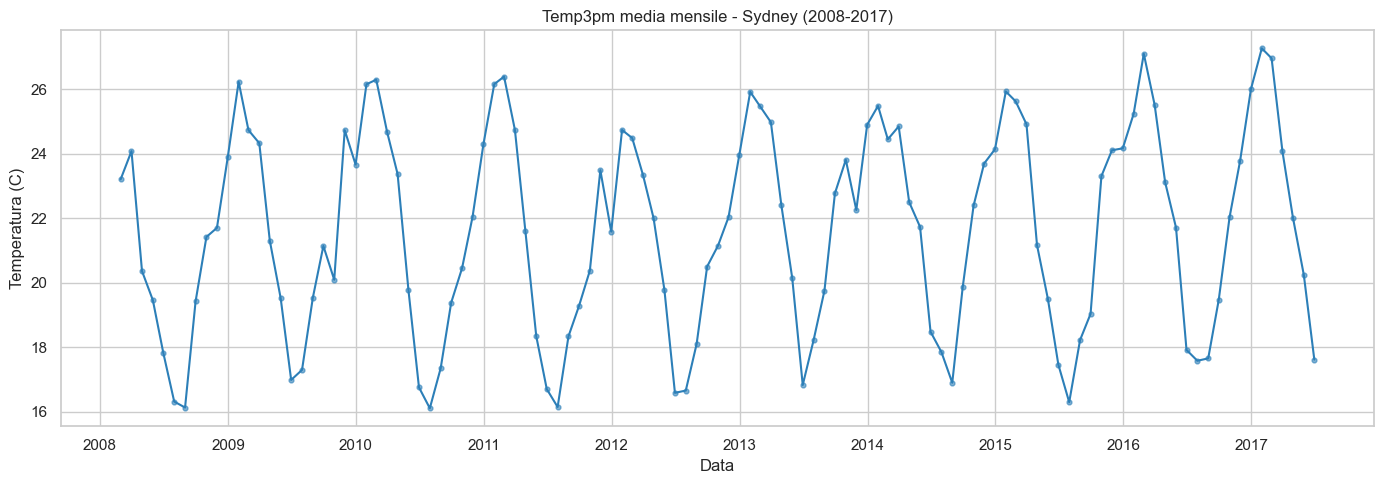

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(serie.index, serie.values, color="#2C7FB8", lw=1.5)
plt.scatter(serie.index, serie.values, s=12, color="#2C7FB8", alpha=.6)
plt.title(f"{VARIABILE} media mensile - {LOCALITA} ({serie.index.min().year}-{serie.index.max().year})")
plt.xlabel("Data"); 
plt.ylabel("Temperatura (C)")
plt.tight_layout(); 
plt.show()

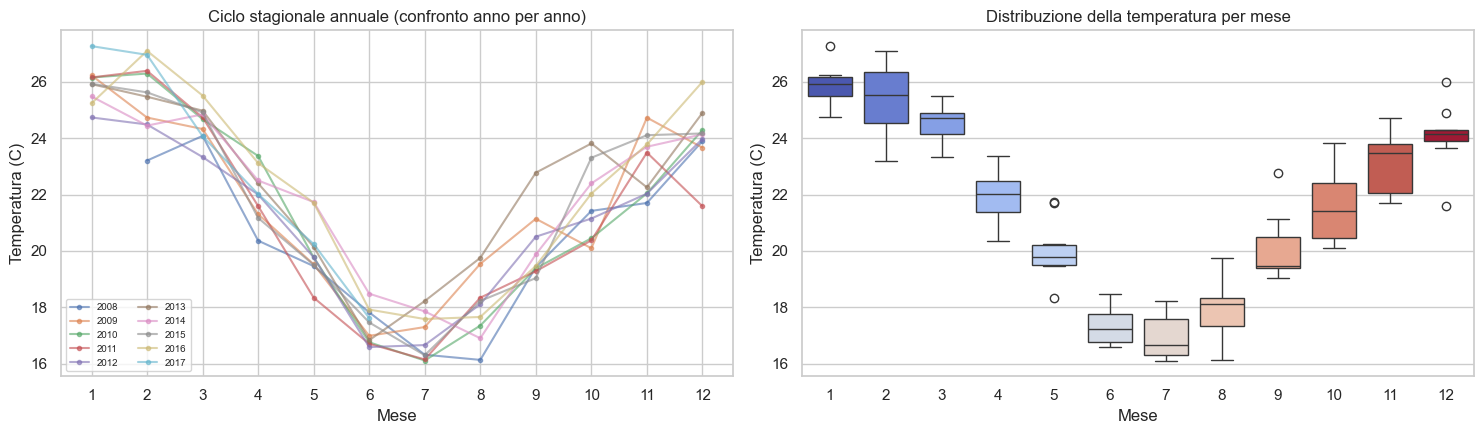

In [7]:
# La stagionalita' vista "ripiegando" gli anni uno sull'altro
tmp = pd.DataFrame({"valore": serie.values}, index=serie.index)
tmp["anno"] = tmp.index.year
tmp["mese"] = tmp.index.month

# GRAFICO A LINEE: Sovrapposizione di ciascun anno
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for anno, g in tmp.groupby("anno"):
    axes[0].plot(g["mese"], g["valore"], marker="o", ms=3, alpha=.6, label=str(anno))
axes[0].set_title("Ciclo stagionale annuale (confronto anno per anno)")
axes[0].set_xlabel("Mese"); axes[0].set_ylabel("Temperatura (C)")
axes[0].set_xticks(range(1, 13)); axes[0].legend(fontsize=7, ncol=2)

# Variabilità e distribuzione mensile delle temperature
sns.boxplot(data=tmp, x="mese", y="valore", hue="mese", palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].set_title("Distribuzione della temperatura per mese")
axes[1].set_xlabel("Mese");
axes[1].set_ylabel("Temperatura (C)")
plt.tight_layout();
plt.show()

### Decomposizione della serie

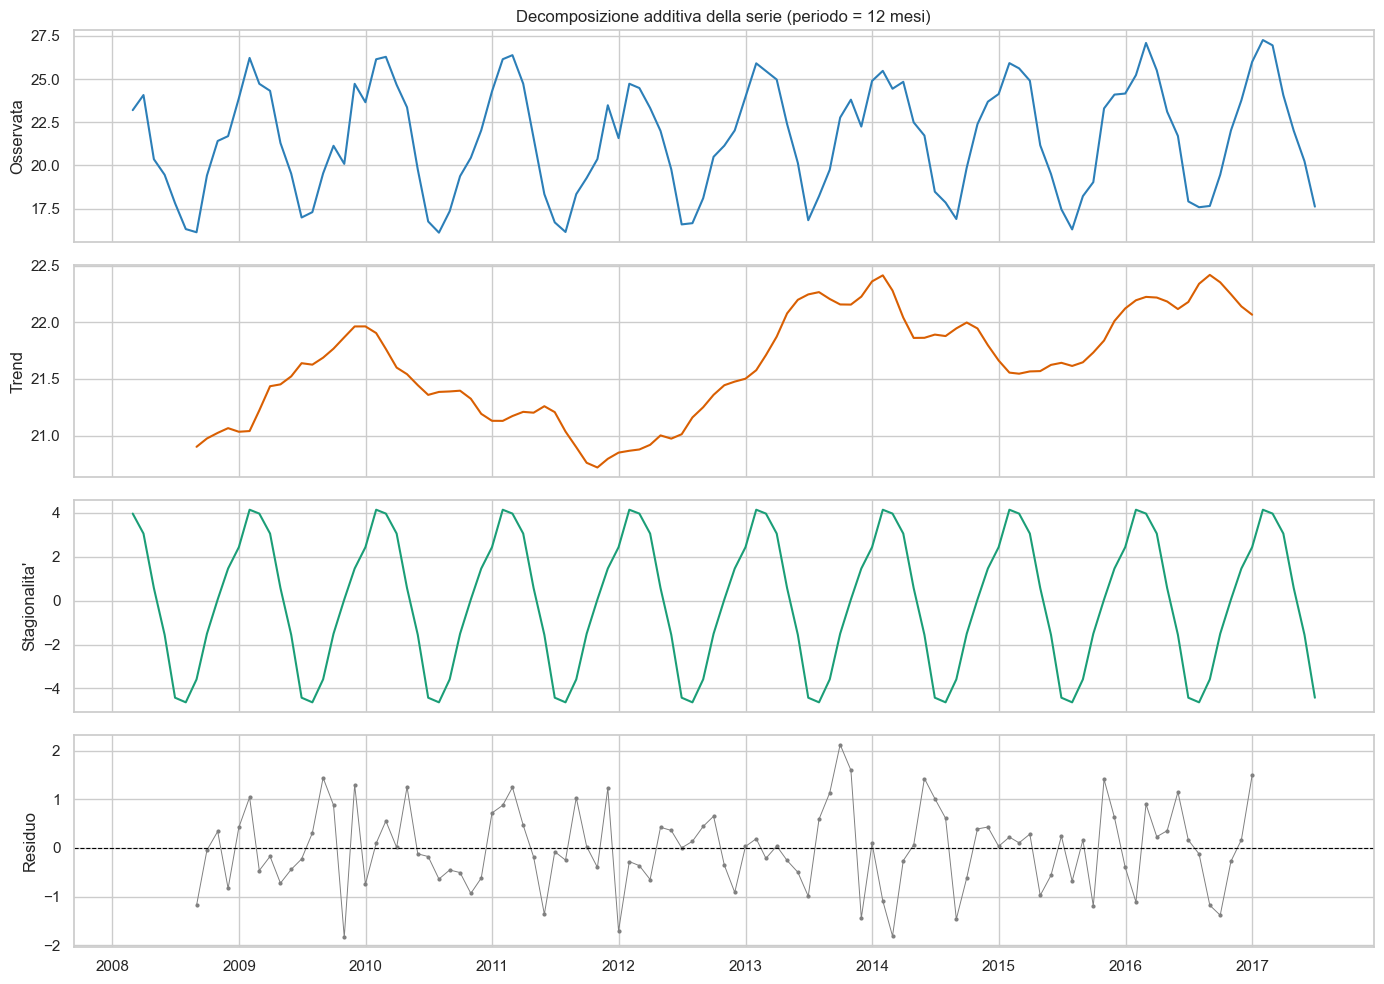

Ampiezza del ciclo stagionale: 8.8 C
Deviazione standard del residuo: 0.83 C


In [8]:
# Scompone la serie in modo additivo con un ciclo di 12 mesi (frequenza annuale)
dec = seasonal_decompose(serie, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
# Serie originale grezza
axes[0].plot(dec.observed, color="#2C7FB8"); 
axes[0].set_ylabel("Osservata")

# Componente di Trend (andamento di lungo periodo)
axes[1].plot(dec.trend, color="#D95F02");   
axes[1].set_ylabel("Trend")

# Componente Stagionale (ciclo ripetitivo di 12 mesi)
axes[2].plot(dec.seasonal, color="#1B9E77");
axes[2].set_ylabel("Stagionalita'")

# Componente Residua (rumore casuale non spiegato)
axes[3].plot(dec.resid, color="grey", marker="o", ms=2, lw=.7); 
axes[3].set_ylabel("Residuo")


axes[3].axhline(0, color="black", lw=.8, ls="--")
axes[0].set_title("Decomposizione additiva della serie (periodo = 12 mesi)")
plt.tight_layout(); 
plt.show()

print(f"Ampiezza del ciclo stagionale: {dec.seasonal.max() - dec.seasonal.min():.1f} C")
print(f"Deviazione standard del residuo: {dec.resid.std():.2f} C")

## Test di stazionarietà

In [9]:
def test_stazionarieta(x, nome):
    """
    Esegue i test statistici ADF e KPSS per verificare la stazionarietà di una serie.
    Rimuove i dati mancanti (dropna) prima di calcolare i test.
    """

    # Estraiamo i primi due valori restituiti: la statistica di test e il p-value
    adf_stat, adf_p = adfuller(x.dropna())[:2]

    # Stazionarietà attorno ad una costante media
    kpss_stat, kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[:2]
    print(f"--- {nome} ---")
    print(f"  ADF : stat={adf_stat:+.3f}  p={adf_p:.4f}  -> "
          f"{'stazionaria' if adf_p < 0.05 else 'NON stazionaria'}")
    print(f"  KPSS: stat={kpss_stat:+.3f}  p={kpss_p:.4f}  -> "
          f"{'NON stazionaria' if kpss_p < 0.05 else 'stazionaria'}")
    return adf_p, kpss_p

test_stazionarieta(serie, "Serie originale")

--- Serie originale ---
  ADF : stat=-1.662  p=0.4508  -> NON stazionaria
  KPSS: stat=+0.094  p=0.1000  -> stazionaria


(np.float64(0.4508090039534957), np.float64(0.1))

### I due test sembrano contraddirsi, ma non è un errore

--- Dopo differenziazione stagionale (D=1, s=12) ---
  ADF : stat=-3.266  p=0.0165  -> stazionaria
  KPSS: stat=+0.081  p=0.1000  -> stazionaria


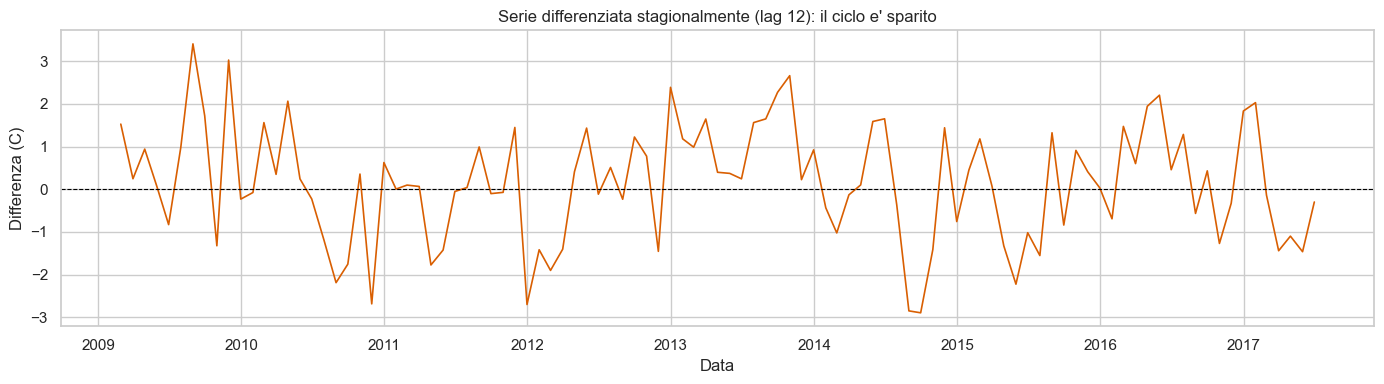

In [10]:
# differenziazione stagionale: valore del mese - valore dello stesso mese dell'anno prima
serie_d12 = serie.diff(12).dropna()
test_stazionarieta(serie_d12, "Dopo differenziazione stagionale (D=1, s=12)")

plt.figure(figsize=(14, 4))
plt.plot(serie_d12.index, serie_d12.values, color="#D95F02", lw=1.2)
plt.axhline(0, color="black", lw=.8, ls="--")
plt.title("Serie differenziata stagionalmente (lag 12): il ciclo e' sparito")
plt.xlabel("Data"); plt.ylabel("Differenza (C)")
plt.tight_layout(); plt.show()

## Identificazione degli ordini con ACF e PACF

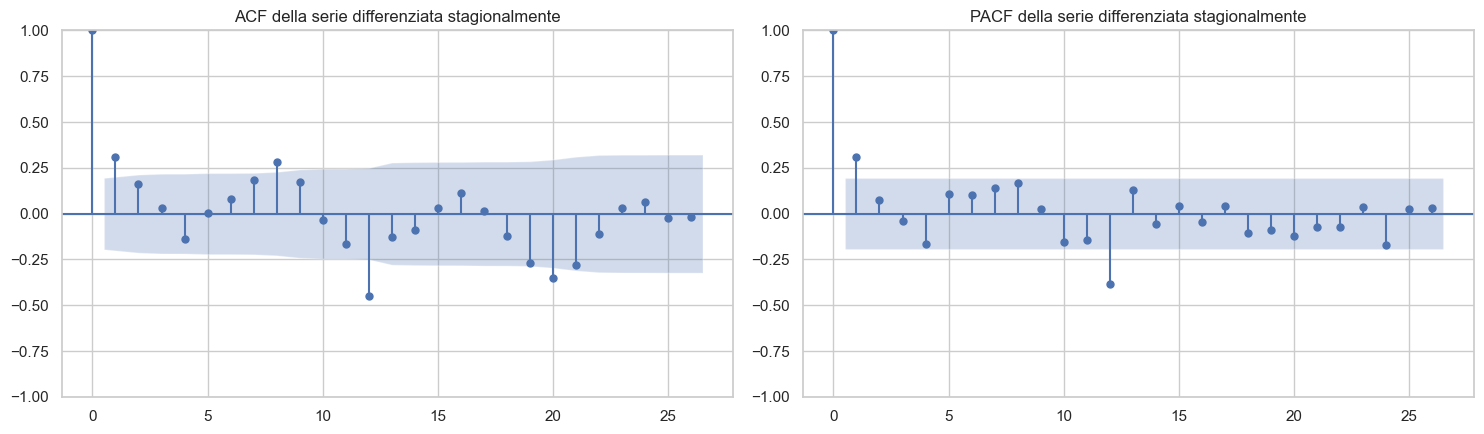

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_acf(serie_d12, lags=26, ax=axes[0])
axes[0].set_title("ACF della serie differenziata stagionalmente")
plot_pacf(serie_d12, lags=26, ax=axes[1], method="ywm")
axes[1].set_title("PACF della serie differenziata stagionalmente")
plt.tight_layout(); plt.show()

### Lettura dei grafici e ordini scelti

In [12]:
# 1. DEFINIZIONE DEL MODELLO MANUALE DI PARTENZA
# Parametri non stagionali: (p, d, q) -> AR(1)
ORDER_MANUALE = (1, 0, 0)
# Parametri stagionali: (P, D, Q, s) -> Differenziazione stagionale + SMA(1)
SORDER_MANUALE = (0, 1, 1, 12)
print("Modello manuale (da ACF/PACF): SARIMAX", ORDER_MANUALE, SORDER_MANUALE)

Modello manuale (da ACF/PACF): SARIMAX (1, 0, 0) (0, 1, 1, 12)


## Validazione: split temporale

Train: 89 mesi (2008-02-29 -> 2015-06-30)
Test : 24 mesi (2015-07-31 -> 2017-06-30)


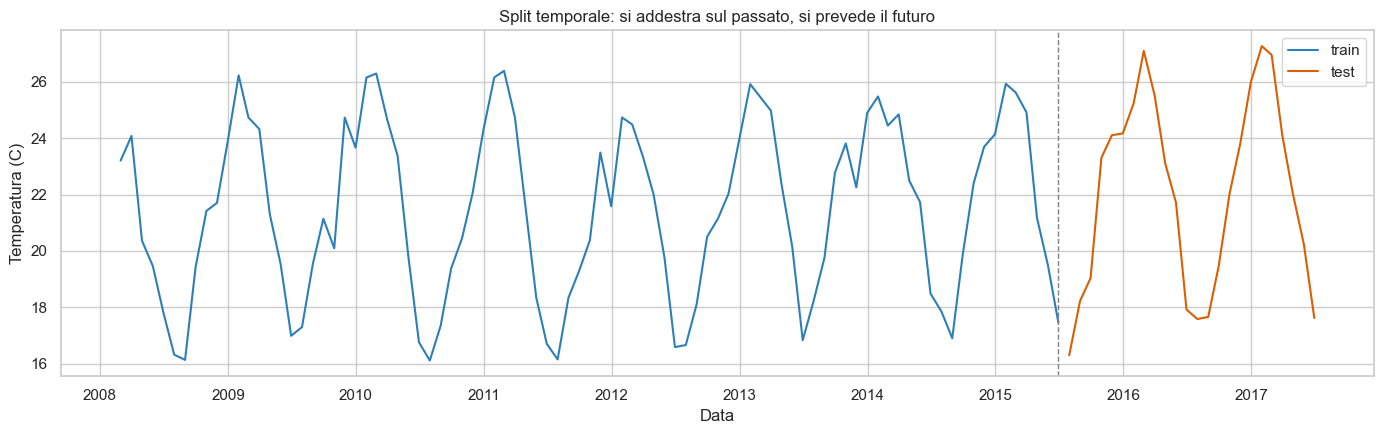

In [13]:
N_TEST = 24
train, test = serie[:-N_TEST], serie[-N_TEST:]

print(f"Train: {len(train)} mesi ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} mesi ({test.index.min().date()} -> {test.index.max().date()})")

plt.figure(figsize=(14, 4.5))
plt.plot(train.index, train.values, label="train", color="#2C7FB8")
plt.plot(test.index, test.values, label="test", color="#D95F02")
plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title("Split temporale: si addestra sul passato, si prevede il futuro")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); plt.show()

## Modellazione

### SARIMAX manuale 

In [14]:
# NOTA: lascio attivi i vincoli di default (enforce_stationarity/invertibility = True)
candidati = [
    ((1, 0, 0), (0, 1, 1, 12)),   # <- proposto da ACF/PACF
    ((0, 0, 1), (0, 1, 1, 12)),
    ((1, 0, 1), (0, 1, 1, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((2, 0, 0), (1, 1, 1, 12)),
    ((1, 0, 1), (1, 1, 0, 12)),
]

righe = []
for order, sorder in candidati:
    m = SARIMAX(train, order=order, seasonal_order=sorder).fit(disp=False)
    righe.append({"order": str(order), "seasonal_order": str(sorder),
                  "AIC": round(m.aic, 1), "BIC": round(m.bic, 1)})

aic_df = pd.DataFrame(righe).sort_values("AIC")
print("Confronto dei candidati (calcolato sul solo training):")
aic_df

Confronto dei candidati (calcolato sul solo training):


,order,seasonal_order,AIC,BIC
0,"(1, 0, 0)","(0, 1, 1, 12)",238.6,245.6
2,"(1, 0, 1)","(0, 1, 1, 12)",238.8,248.2
1,"(0, 0, 1)","(0, 1, 1, 12)",240.7,247.7
4,"(2, 0, 0)","(1, 1, 1, 12)",241.2,253.0
5,"(1, 0, 1)","(1, 1, 0, 12)",245.1,254.5
3,"(1, 0, 0)","(1, 1, 0, 12)",246.1,253.1


In [15]:
# addestro il modello manuale scelto da ACF/PACF
sarimax_man = SARIMAX(train, order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)
print(sarimax_man.summary().tables[0])
print(sarimax_man.summary().tables[1])

                                      SARIMAX Results                                       
Dep. Variable:                              Temp3pm   No. Observations:                   89
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -116.285
Date:                              Wed, 22 Jul 2026   AIC                            238.570
Time:                                      23:18:56   BIC                            245.601
Sample:                                  02-29-2008   HQIC                           241.383
                                       - 06-30-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3510      0.096      3.674      0.000       0.164       0.538
ma.S.L12      -0.99

### auto-ARIMA

In [16]:
try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("pmdarima non installato -> salto auto-ARIMA.  pip install pmdarima")

if HAS_PMDARIMA:
    auto_model = auto_arima(train, seasonal=True, m=12, d=0, D=1,
                            start_p=0, max_p=3, start_q=0, max_q=3,
                            max_P=2, max_Q=2, stepwise=True,
                            suppress_warnings=True, error_action="ignore", trace=False)
    print("auto-ARIMA -> ordini scelti:", auto_model.order, auto_model.seasonal_order)
    print(auto_model.summary().tables[0])

auto-ARIMA -> ordini scelti: (1, 0, 1) (1, 1, 0, 12)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   89
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood                -118.543
Date:                             Wed, 22 Jul 2026   AIC                            245.085
Time:                                     23:19:10   BIC                            254.460
Sample:                                 02-29-2008   HQIC                           248.835
                                      - 06-30-2015                                         
Covariance Type:                               opg                                         


### SARIMAX con variabili esogene 

In [17]:
# Selezione e preparazone delle variabili esogene 
EXOG_VARS = ["Humidity3pm", "Pressure3pm"]

# esogene mensili per la stessa localita', allineate all'indice di 'serie'
exog_mensile = (df[df["Location"] == LOCALITA]
                .set_index("Date")[EXOG_VARS].sort_index()
                .resample(FREQ).mean())
# Allineamento dell'indice temporale e pulizia dei valori mancanti
exog_mensile = exog_mensile.reindex(serie.index).interpolate(method="time").bfill().ffill()

exog_train, exog_test = exog_mensile.iloc[:-N_TEST], exog_mensile.iloc[-N_TEST:]

sarimax_exog = SARIMAX(train, exog=exog_train,
                       order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)

print("Coefficienti delle variabili esogene (p<0.05 = effetto significativo):")
print(sarimax_exog.summary().tables[1])

Coefficienti delle variabili esogene (p<0.05 = effetto significativo):
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Humidity3pm    -0.1109      0.026     -4.243      0.000      -0.162      -0.060
Pressure3pm     0.0345      0.043      0.806      0.420      -0.049       0.118
ar.L1           0.2665      0.133      1.997      0.046       0.005       0.528
ma.S.L12       -0.9984     49.211     -0.020      0.984     -97.451      95.454
sigma2          0.6634     32.596      0.020      0.984     -63.223      64.550


## Forecast e metriche di errore

In [18]:
def metriche(nome, reale, pred):
    mae = mean_absolute_error(reale, pred)
    rmse = np.sqrt(mean_squared_error(reale, pred))
    mape = np.mean(np.abs((reale - pred) / reale)) * 100
    return {"Modello": nome, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "MAPE %": round(mape, 2)}

# previsioni con intervalli di confidenza
fc_man = sarimax_man.get_forecast(steps=N_TEST)
pred_man = fc_man.predicted_mean
ci_man = fc_man.conf_int()

risultati = [metriche(f"SARIMAX manuale {ORDER_MANUALE}{SORDER_MANUALE}", test, pred_man)]

# Aggiunta dell'auto-ARIMA se la libreria è presente
if HAS_PMDARIMA:
    pred_auto = pd.Series(auto_model.predict(n_periods=N_TEST), index=test.index)
    risultati.append(metriche(f"auto-ARIMA {auto_model.order}{auto_model.seasonal_order}",
                              test, pred_auto))

# baseline: stesso mese dell'anno precedente
pred_naive = serie.shift(12)[-N_TEST:]
risultati.append(metriche("Baseline naive stagionale", test, pred_naive))

res_df = pd.DataFrame(risultati).sort_values("MAE")
res_df

,Modello,MAE,RMSE,MAPE %
1,"auto-ARIMA (1, 0, 1)(1, 1, 0, 12)",0.863,1.104,3.83
0,"SARIMAX manuale (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37
2,Baseline naive stagionale,1.026,1.201,4.72


,MAE,RMSE,MAPE %
Modello,,,
"SARIMAX manuale (1, 0, 0)(0, 1, 1, 12)",0.995,1.176,4.37
"auto-ARIMA (1, 0, 1)(1, 1, 0, 12)",0.863,1.104,3.83
Baseline naive stagionale,1.026,1.201,4.72
"SARIMAX + esogene ['Humidity3pm', 'Pressure3pm']",0.727,0.863,3.24


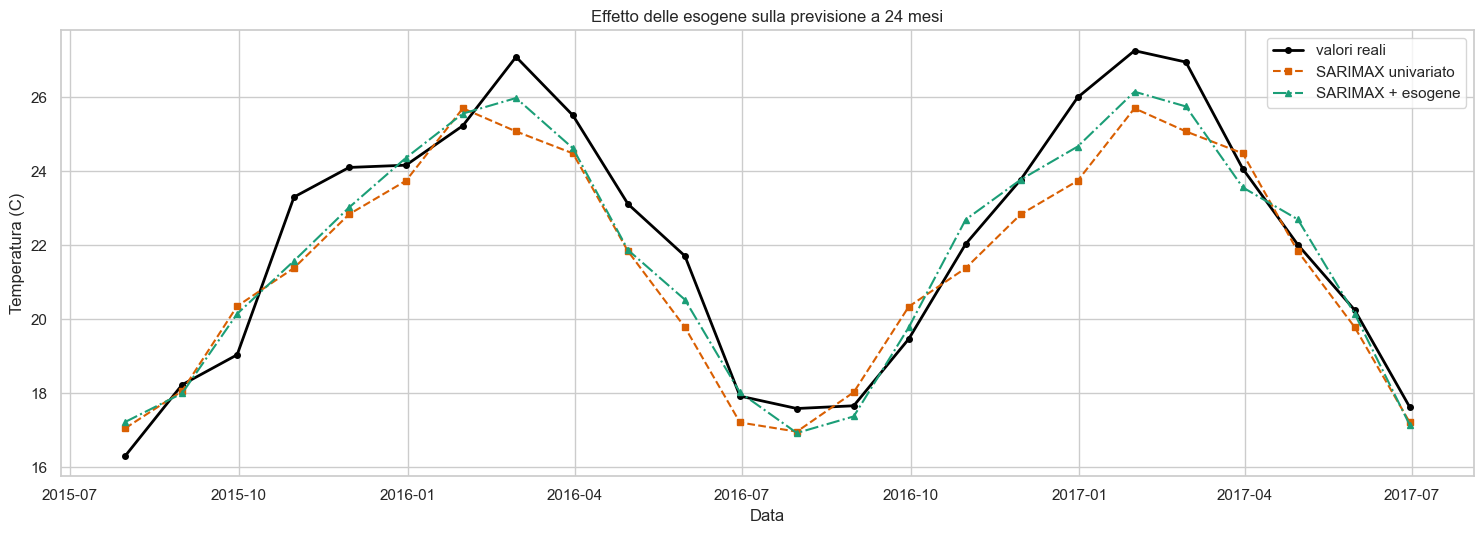

In [19]:
# PREVISIONE CON MODELLO ESOGENO (SARIMAX + COVARIATE)
fc_exog = sarimax_exog.get_forecast(steps=N_TEST, exog=exog_test)
pred_exog = fc_exog.predicted_mean

# non muto 'risultati': ne creo una copia estesa con il modello esogeno
risultati_completo = risultati + [metriche(f"SARIMAX + esogene {EXOG_VARS}", test, pred_exog)]
display(pd.DataFrame(risultati_completo).set_index("Modello"))

# GRAFICO COMPARATIVO TRA REALE E PREVISIONI SUL TEST SET
plt.figure(figsize=(15, 5.5))
plt.plot(test.index, test.values, label="valori reali", color="black", lw=2, marker="o", ms=4)
plt.plot(test.index, pred_man, label="SARIMAX univariato", color="#D95F02", ls="--", marker="s", ms=4)
plt.plot(test.index, pred_exog, label="SARIMAX + esogene", color="#1B9E77", ls="-.", marker="^", ms=4)
plt.title(f"Effetto delle esogene sulla previsione a {N_TEST} mesi")
plt.xlabel("Data"); 
plt.ylabel("Temperatura (C)"); 
plt.legend()
plt.tight_layout(); 
plt.show()

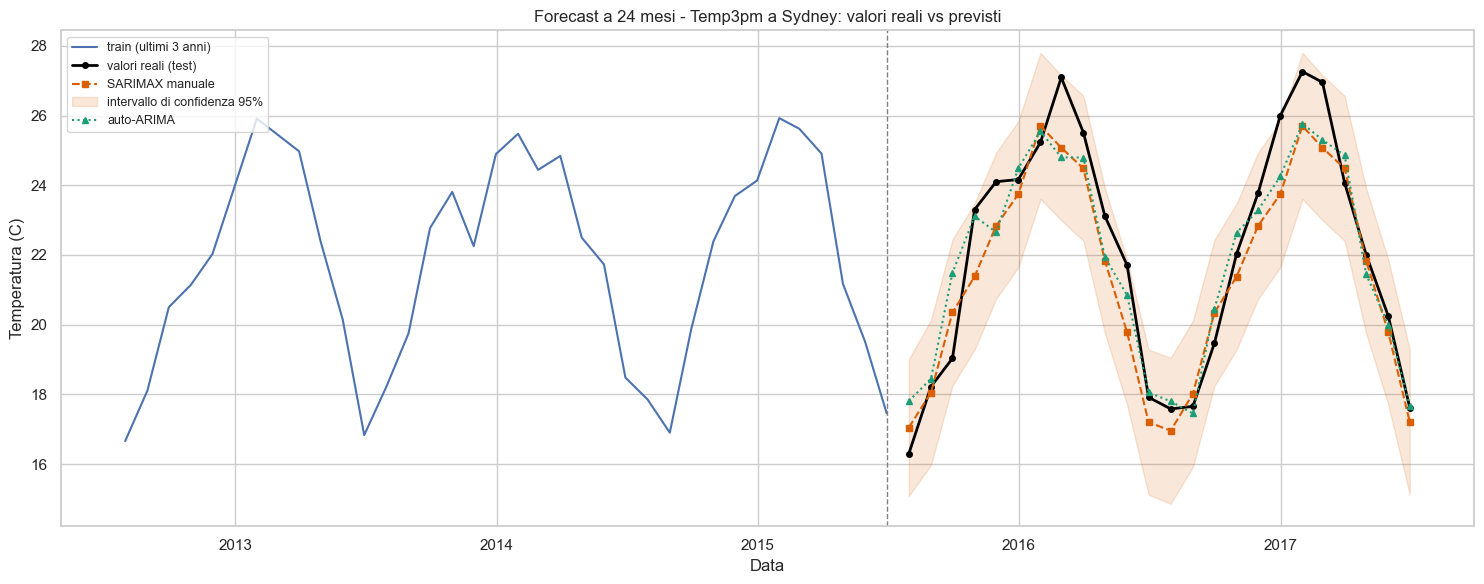

In [20]:
plt.figure(figsize=(15, 6))

# Traccia gli ultimi 36 mesi di addestramento per contestualizzare la partenza della curva
plt.plot(train.index[-36:], train.values[-36:], label="train (ultimi 3 anni)", color="#4C72B0")

# Traccia i dati reali effettivi sul Test Set
plt.plot(test.index, test.values, label="valori reali (test)", color="black", lw=2, marker="o", ms=4)

# Previsione puntuale del SARIMAX manuale
plt.plot(test.index, pred_man, label="SARIMAX manuale", color="#D95F02", ls="--", marker="s", ms=4)

# Area d'incertezza al 95% della previsione (Intervallo di Confidenza)
plt.fill_between(test.index, ci_man.iloc[:, 0], ci_man.iloc[:, 1],
                 color="#D95F02", alpha=.15, label="intervallo di confidenza 95%")

# Eventuale curva dell'Auto-ARIMA per confronto diretto
if HAS_PMDARIMA:
    plt.plot(test.index, pred_auto, label="auto-ARIMA", color="#1B9E77", ls=":", marker="^", ms=4)

# Linea di demarcazione temporale tra Train e Test
plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Forecast a {N_TEST} mesi - {VARIABILE} a {LOCALITA}: valori reali vs previsti")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

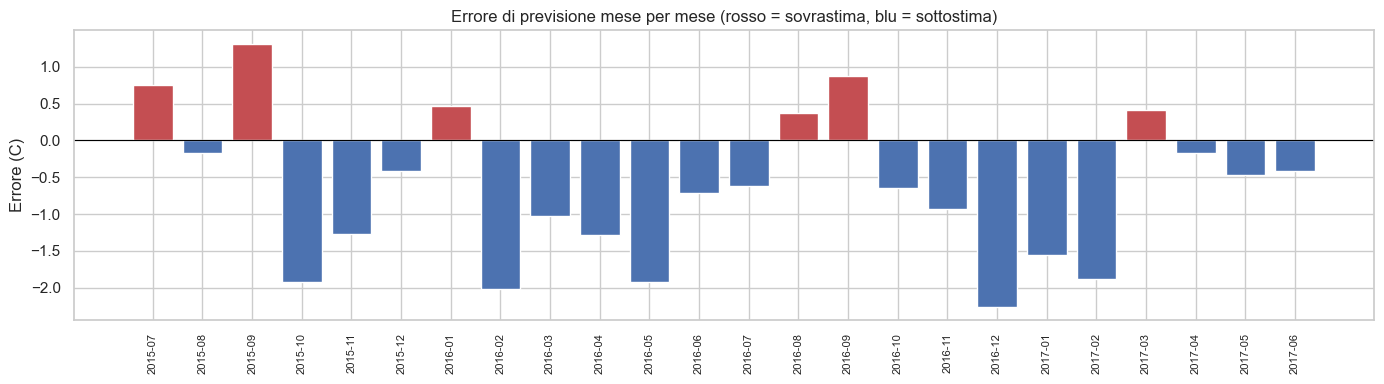

Errore medio (bias): -0.646 C
Errore massimo:      2.255 C


In [21]:
# errore mese per mese: dove sbaglia di piu' il modello?
errori = pd.DataFrame({"reale": test, "previsto": pred_man})
errori["errore"] = errori["previsto"] - errori["reale"]

plt.figure(figsize=(14, 4))

# Colorazione condizionale: Rosso = sovrastima, Blu = sottostima
colori = ["#C44E52" if e > 0 else "#4C72B0" for e in errori["errore"]]
plt.bar(range(len(errori)), errori["errore"], color=colori)
plt.axhline(0, color="black", lw=.8)
plt.xticks(range(len(errori)), [d.strftime("%Y-%m") for d in errori.index], rotation=90, fontsize=8)
plt.title("Errore di previsione mese per mese (rosso = sovrastima, blu = sottostima)")
plt.ylabel("Errore (C)")
plt.tight_layout(); plt.show()

print(f"Errore medio (bias): {errori['errore'].mean():+.3f} C")
print(f"Errore massimo:      {errori['errore'].abs().max():.3f} C")

## Diagnostica dei residui

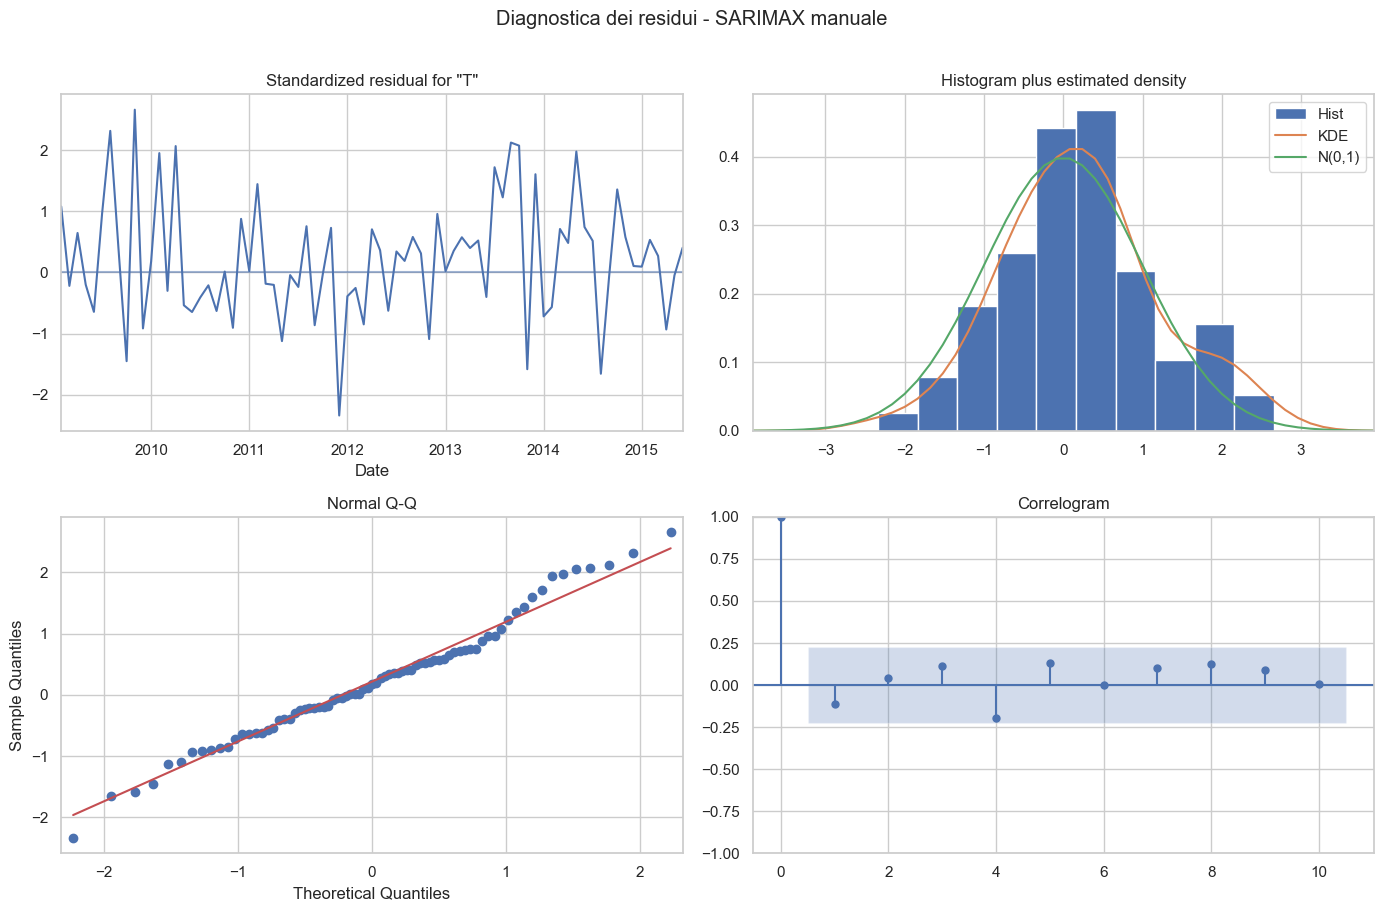

In [22]:
sarimax_man.plot_diagnostics(figsize=(14, 9))
plt.suptitle("Diagnostica dei residui - SARIMAX manuale", y=1.01)
plt.tight_layout(); plt.show()

In [23]:
SKIP = 12   # mesi di inizializzazione della differenziazione stagionale
resid = sarimax_man.resid[SKIP:]

# Eseguiamo il test di Ljung-Box sui lag 6, 12, 18 e 24
lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
print("Test di Ljung-Box (H0: residui indipendenti -> vogliamo p > 0.05):")
print(lb.round(4).to_string())

print(f"\nMedia dei residui: {resid.mean():+.3f} (attesa ~0)")
print(f"Deviazione standard: {resid.std():.3f}")

# confronto: cosa succederebbe SENZA scartare i primi 12 (errore da evitare)
lb_sbagliato = acorr_ljungbox(sarimax_man.resid, lags=[12], return_df=True)
print(f"\n[Controprova] Ljung-Box sui residui grezzi -> p = {lb_sbagliato['lb_pvalue'].iloc[0]:.4f} ")

Test di Ljung-Box (H0: residui indipendenti -> vogliamo p > 0.05):
    lb_stat  lb_pvalue
6    7.4964     0.2774
12  10.7555     0.5500
18  11.3657     0.8782
24  17.1543     0.8420

Media dei residui: +0.242 (attesa ~0)
Deviazione standard: 1.112

[Controprova] Ljung-Box sui residui grezzi -> p = 0.0000 


## Previsione futura

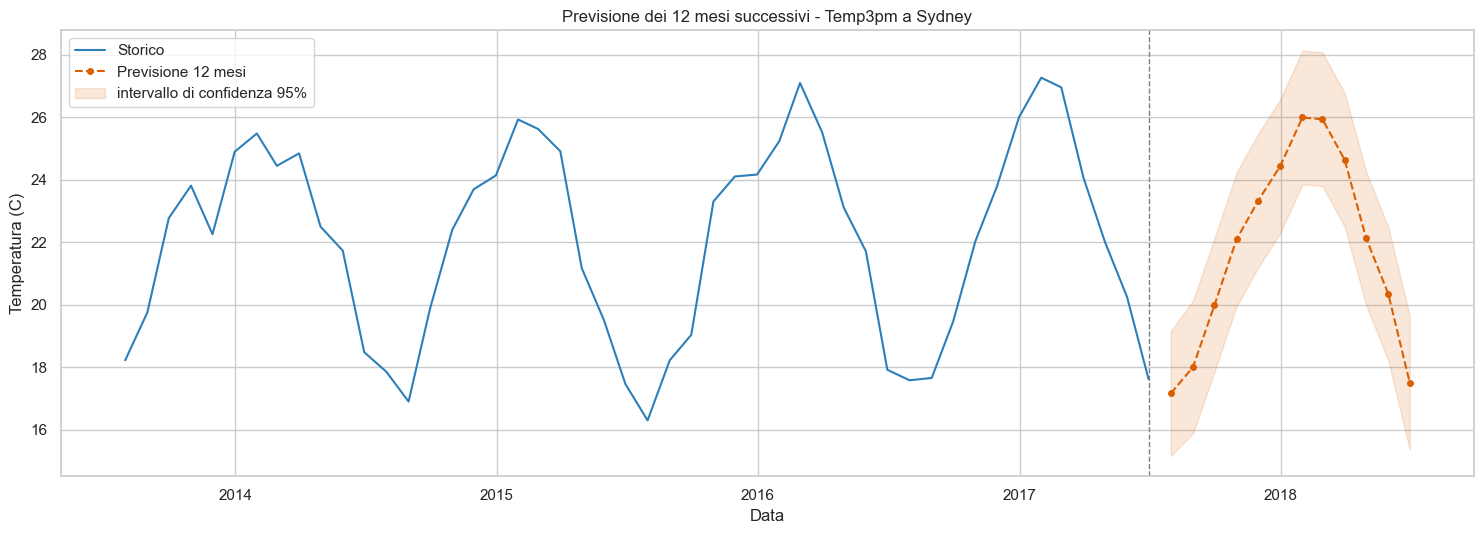

Previsione dei prossimi 12 mesi (C):
            previsione  IC 95% inf  IC 95% sup
2017-07-31        17.2        15.2        19.2
2017-08-31        18.0        15.9        20.1
2017-09-30        20.0        17.8        22.1
2017-10-31        22.1        20.0        24.2
2017-11-30        23.3        21.2        25.5
2017-12-31        24.4        22.3        26.6
2018-01-31        26.0        23.8        28.1
2018-02-28        25.9        23.8        28.1
2018-03-31        24.6        22.5        26.8
2018-04-30        22.1        20.0        24.3
2018-05-31        20.3        18.2        22.5
2018-06-30        17.5        15.4        19.6


In [24]:
# Addestriamo il modello definitivo su TUTTA la serie storica disponibile
modello_finale = SARIMAX(serie, order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE).fit(disp=False)

# Calcolo del forecast per i 12 mesi futuri oltre la fine del dataset
fc_fut = modello_finale.get_forecast(steps=12)
pred_fut = fc_fut.predicted_mean
ci_fut = fc_fut.conf_int()

# Visualizzazione grafica degli ultimi 4 anni e della proiezione futura a 12 mesi
plt.figure(figsize=(15, 5.5))
plt.plot(serie.index[-48:], serie.values[-48:], label="Storico", color="#2C7FB8")
plt.plot(pred_fut.index, pred_fut.values, label="Previsione 12 mesi", color="#D95F02",
         ls="--", marker="o", ms=4)
plt.fill_between(pred_fut.index, ci_fut.iloc[:, 0], ci_fut.iloc[:, 1],
                 color="#D95F02", alpha=.15, label="intervallo di confidenza 95%")
plt.axvline(serie.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Previsione dei 12 mesi successivi - {VARIABILE} a {LOCALITA}")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); plt.show()

print("Previsione dei prossimi 12 mesi (C):")
print(pd.DataFrame({"previsione": pred_fut.round(1),
                    "IC 95% inf": ci_fut.iloc[:, 0].round(1),
                    "IC 95% sup": ci_fut.iloc[:, 1].round(1)}).to_string())